In [1]:
# Imports
from os import listdir
from os.path import isfile, join
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from timeit import default_timer as timer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Activation, MaxPooling1D, Dropout, LSTM
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize

np.random.seed(10)
from tensorflow.keras import backend as K
K.clear_session()


In [2]:
pip install streamlit librosa tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras.models import load_model

model = load_model('final_model.h5')
print("Model loaded successfully.")

OSError: No file or directory found at final_model.h5

In [4]:
# Diagnosis Class
class Diagnosis():
    def __init__ (self, id, diagnosis, image_path):
        self.id = id
        self.diagnosis = diagnosis 
        self.image_path = image_path   

In [5]:
# get_wav_files function
def get_wav_files():
    audio_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'
    files = [f for f in listdir(audio_path) if isfile(join(audio_path, f))]
    wav_files = [f for f in files if f.endswith('.wav')]
    wav_files = sorted(wav_files)
    return wav_files, audio_path

In [6]:
# diagnosis_data function
def diagnosis_data():
    diagnosis = pd.read_csv('extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv')
    
    wav_files, audio_path = get_wav_files()
    diag_dict = { 101 : "URTI"}   
    diagnosis_list = []
    
    for index , row in diagnosis.iterrows():
        diag_dict[row[0]] = row.iloc[1]     

    c = 0
    for f in wav_files:
        diagnosis_list.append(Diagnosis(c, diag_dict[int(f[:3])], audio_path+f))
        c+=1

    return diagnosis_list

In [7]:
# audio_features function
def audio_features(filename):
    """
    Extracts features from an audio file without any data augmentation.
    This function is now safe to use with any .wav file.
    """
    try:
        sound, sample_rate = librosa.load(filename)
        stft = np.abs(librosa.stft(sound))
        
        mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40),axis=1)
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate),axis=1)
        mel = np.mean(librosa.feature.melspectrogram(y=sound, sr=sample_rate), axis=1)
        contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate),axis=1)
        tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate),axis=1)
            
        concat = np.concatenate((mfccs,chroma,mel,contrast,tonnetz))
        return concat
    except Exception as e:
        print(f"Error processing file {filename}: {e}")
        return None

# Data Points function
def data_points():
    labels = []
    images = []

    to_hot_one = {"COPD":0, "Healthy":1, "URTI":2, "Bronchiectasis":3, "Pneumonia":4, "Bronchiolitis":5, "Asthma":6, "LRTI":7}

    count = 0
    diagnosis_list = diagnosis_data()
    for f in diagnosis_list:
        print(f"Processing {count+1}/{len(diagnosis_list)}: {f.image_path}")
        
        try:
            # Data augmentation for minority classes
            diagnosis_label = f.diagnosis
            if diagnosis_label in ["URTI", "Bronchiectasis", "Pneumonia", "Bronchiolitis"]:
                for _ in range(5):
                    sound, sample_rate = librosa.load(f.image_path)
                    
                    noise = np.random.randn(len(sound))
                    sound_augmented = sound + 0.005 * noise
                    
                    stft = np.abs(librosa.stft(sound_augmented))
                    mfccs = np.mean(librosa.feature.mfcc(y=sound_augmented, sr=sample_rate, n_mfcc=40), axis=1)
                    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate), axis=1)
                    mel = np.mean(librosa.feature.melspectrogram(y=sound_augmented, sr=sample_rate), axis=1)
                    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate), axis=1)
                    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound_augmented), sr=sample_rate), axis=1)
                    concat = np.concatenate((mfccs, chroma, mel, contrast, tonnetz))
                    
                    labels.append(to_hot_one[diagnosis_label])
                    images.append(concat)

            sound, sample_rate = librosa.load(f.image_path)
            stft = np.abs(librosa.stft(sound))
            mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40), axis=1)
            chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate), axis=1)
            mel = np.mean(librosa.feature.melspectrogram(y=sound, sr=sample_rate), axis=1)
            contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate), axis=1)
            tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate), axis=1)
            concat = np.concatenate((mfccs, chroma, mel, contrast, tonnetz))
            
            labels.append(to_hot_one[diagnosis_label])
            images.append(concat)
        
        except Exception as e:
            print(f"Error processing file: {f.image_path}. Skipping this file. Error: {e}")
            
        count += 1

    return np.array(labels), np.array(images)

C:\Users\naman\AppData\Local\Temp\ipykernel_23792\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


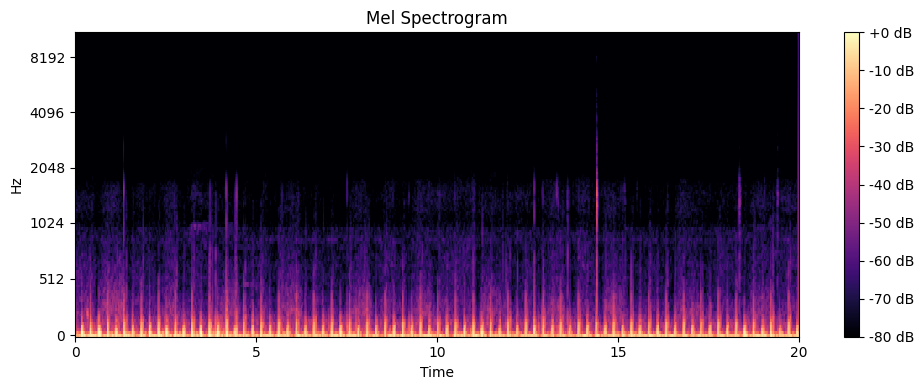

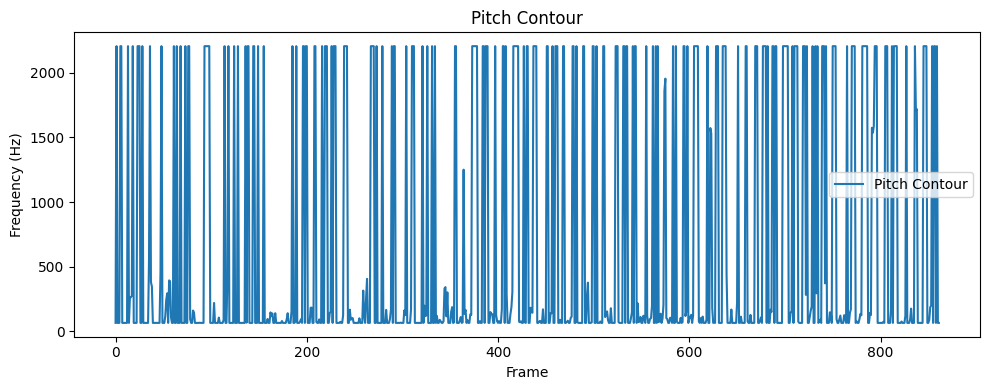

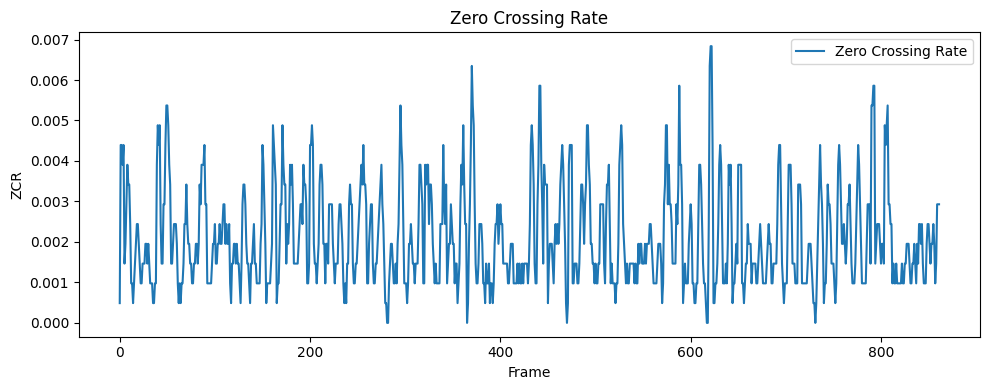

In [8]:
# Audio feature visualization
sample_path = diagnosis_data()[0].image_path
y, sr = librosa.load(sample_path)

plt.figure(figsize=(10, 4))
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))

plt.figure(figsize=(10, 4))
plt.plot(f0, label='Pitch Contour')
plt.xlabel('Frame')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Contour')
plt.legend()
plt.tight_layout()
plt.show()

zcr = librosa.feature.zero_crossing_rate(y)[0]

plt.figure(figsize=(10, 4))
plt.plot(zcr, label='Zero Crossing Rate')
plt.xlabel('Frame')
plt.ylabel('ZCR')
plt.title('Zero Crossing Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Preprocessing
def preprocessing(labels, images):
    images = np.delete(images, np.where((labels == 7) | (labels == 6))[0], axis=0) 
    labels = np.delete(labels, np.where((labels == 7) | (labels == 6))[0], axis=0)     
    return images, labels

In [10]:
# Data preparation
start = timer()
try:
    labels, images = data_points()
    images, labels = preprocessing(labels, images)
    print('Final shapes:', images.shape, labels.shape)
except Exception as e:
    print(f"Error during data preparation: {e}")
print('Time taken: ', (timer() - start))

C:\Users\naman\AppData\Local\Temp\ipykernel_23792\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


Processing 1/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav


c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing 2/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Pr_sc_Meditron.wav
Processing 3/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/102_1b1_Ar_sc_Meditron.wav
Processing 4/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/103_2b2_Ar_mc_LittC2SE.wav
Processing 5/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Al_sc_Litt3200.wav
Processing 6/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Ar_sc_Litt3200.wav
Processing 7/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Ll_sc_Litt3200.wav
Processing 8/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Lr_sc_Litt3200.wav
Processing 9/920: extracted_dataset/Respi

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing 910/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Ar_sc_Meditron.wav
Processing 911/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Ll_sc_Meditron.wav
Processing 912/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Lr_sc_Meditron.wav
Processing 913/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Pl_sc_Meditron.wav
Processing 914/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Pr_sc_Meditron.wav
Processing 915/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/224_1b1_Tc_sc_Meditron.wav
Processing 916/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/224_1b2_Al_sc_Meditron.wav
Processing 917/920: extract

In [11]:
# Model Architectures & K-Fold Training
def build_cnn_model():
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(images.shape[1], 1)))
    model.add(Conv1D(128, kernel_size=5, activation='relu'))
    model.add(MaxPooling1D(2)) 
    model.add(Conv1D(256, kernel_size=5, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))    
    model.add(Dense(6, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_hybrid_model():
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(images.shape[1], 1)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(128, kernel_size=5, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))
    model.add(LSTM(64, return_sequences=True))  # Add an LSTM layer
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(6, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [12]:
model = build_hybrid_model()

# K-Fold Cross-Validation Setup
n_splits = 5 
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=10)

fold_no = 1
histories = []
all_preds = []
all_y_test = []
all_test_losses = []
all_test_accuracies = [] 
all_prob_preds = []     
all_y_test_cat = []      

for train_index, test_index in skf.split(images, labels):
    print(f"----------------------------------- Fold {fold_no} -----------------------------------")
    
    X_train, X_test = images[train_index], images[test_index]
    y_train, y_test = labels[train_index], labels[test_index]

    # Preprocessing
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Calculate class weights for the current fold
    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(class_weights))

    # Define callbacks for training
    callbacks = [
        ModelCheckpoint(f'model_fold_{fold_no}.h5', monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, verbose=1)
    ]
    
    model = build_hybrid_model()
    history = model.fit(
        X_train, 
        y_train_cat, 
        validation_data=(X_test, y_test_cat), 
        epochs=100, 
        batch_size=200, 
        verbose=1,
        class_weight=class_weights,
        callbacks=callbacks
    )
    histories.append(history)

    # Evaluate the best model from the fold
    from tensorflow.keras.models import Sequential, Model, load_model
    best_model = load_model(f'model_fold_{fold_no}.h5')
    score = best_model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Fold {fold_no} - Test Loss: {score[0]:.4f}, Test Accuracy: {score[1]:.2%}")
    
    # Append the scores to our new lists
    all_test_losses.append(score[0])
    all_test_accuracies.append(score[1])

    # Store predictions for the confusion matrix and classification report
    preds = best_model.predict(X_test, verbose=0)
    all_prob_preds.extend(preds)                 
    all_preds.extend(np.argmax(preds, axis=1))
    all_y_test.extend(y_test)
    all_y_test_cat.extend(y_test_cat)          

    fold_no += 1



----------------------------------- Fold 1 -----------------------------------
Epoch 1/100


6/6 [==============================] - ETA: 0s - loss: 1.8466 - accuracy: 0.2828
Epoch 1: val_loss improved from inf to 1.39645, saving model to model_fold_1.h5
6/6 [==============================] - 4s 244ms/step - loss: 1.8466 - accuracy: 0.2828 - val_loss: 1.3964 - val_accuracy: 0.4945 - lr: 0.0010
Epoch 2/100
1/6 [====>.........................] - ETA: 0s - loss: 1.3001 - accuracy: 0.3750

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - ETA: 0s - loss: 1.4825 - accuracy: 0.5574
Epoch 2: val_loss improved from 1.39645 to 1.08393, saving model to model_fold_1.h5
6/6 [==============================] - 1s 124ms/step - loss: 1.4825 - accuracy: 0.5574 - val_loss: 1.0839 - val_accuracy: 0.6007 - lr: 0.0010
Epoch 3/100
6/6 [==============================] - ETA: 0s - loss: 1.3252 - accuracy: 0.5859
Epoch 3: val_loss improved from 1.08393 to 0.92314, saving model to model_fold_1.h5
6/6 [==============================] - 1s 105ms/step - loss: 1.3252 - accuracy: 0.5859 - val_loss: 0.9231 - val_accuracy: 0.6374 - lr: 0.0010
Epoch 4/100
6/6 [==============================] - ETA: 0s - loss: 1.1358 - accuracy: 0.6841
Epoch 4: val_loss did not improve from 0.92314
6/6 [==============================] - 1s 128ms/step - loss: 1.1358 - accuracy: 0.6841 - val_loss: 1.0884 - val_accuracy: 0.6044 - lr: 0.0010
Epoch 5/100
6/6 [==============================] - ETA: 0s - loss: 1.0749 - accuracy: 0.6400

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/6 [========================>.....] - ETA: 0s - loss: 1.4186 - accuracy: 0.6140
Epoch 2: val_loss improved from 1.06113 to 0.89447, saving model to model_fold_2.h5
6/6 [==============================] - 1s 86ms/step - loss: 1.3798 - accuracy: 0.6143 - val_loss: 0.8945 - val_accuracy: 0.6557 - lr: 0.0010
Epoch 3/100
5/6 [========================>.....] - ETA: 0s - loss: 1.1938 - accuracy: 0.6440
Epoch 3: val_loss did not improve from 0.89447
6/6 [==============================] - 1s 90ms/step - loss: 1.2059 - accuracy: 0.6391 - val_loss: 0.9809 - val_accuracy: 0.5714 - lr: 0.0010
Epoch 4/100
5/6 [========================>.....] - ETA: 0s - loss: 1.1490 - accuracy: 0.6780
Epoch 4: val_loss did not improve from 0.89447
6/6 [==============================] - 0s 80ms/step - loss: 1.1445 - accuracy: 0.6768 - val_loss: 0.9508 - val_accuracy: 0.6630 - lr: 0.0010
Epoch 5/100
6/6 [==============================] - ETA: 0s - loss: 1.0779 - accuracy: 0.6446
Epoch 5: val_loss improved from 0.89447

...

5/6 [========================>.....] - ETA: 0s - loss: 1.3385 - accuracy: 0.6350
Epoch 2: val_loss improved from 1.21244 to 1.16223, saving model to model_fold_3.h5
6/6 [==============================] - 1s 95ms/step - loss: 1.3395 - accuracy: 0.6312 - val_loss: 1.1622 - val_accuracy: 0.5662 - lr: 0.0010
Epoch 3/100
5/6 [========================>.....] - ETA: 0s - loss: 1.1637 - accuracy: 0.6470
Epoch 3: val_loss did not improve from 1.16223
6/6 [==============================] - 1s 95ms/step - loss: 1.1662 - accuracy: 0.6422 - val_loss: 1.3007 - val_accuracy: 0.5772 - lr: 0.0010
Epoch 4/100
6/6 [==============================] - ETA: 0s - loss: 1.1082 - accuracy: 0.6486
Epoch 4: val_loss improved from 1.16223 to 0.65648, saving model to model_fold_3.h5
6/6 [==============================] - 1s 95ms/step - loss: 1.1082 - accuracy: 0.6486 - val_loss: 0.6565 - val_accuracy: 0.7537 - lr: 0.0010
Epoch 5/100
6/6 [==============================] - ETA: 0s - loss: 0.9084 - accuracy: 0.7275
Ep

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/6 [========================>.....] - ETA: 0s - loss: 1.5242 - accuracy: 0.5940
Epoch 2: val_loss did not improve from 1.10366
6/6 [==============================] - 0s 76ms/step - loss: 1.4718 - accuracy: 0.5982 - val_loss: 1.2298 - val_accuracy: 0.5772 - lr: 0.0010
Epoch 3/100
5/6 [========================>.....] - ETA: 0s - loss: 1.2465 - accuracy: 0.5780
Epoch 3: val_loss improved from 1.10366 to 0.90730, saving model to model_fold_4.h5
6/6 [==============================] - 1s 90ms/step - loss: 1.2597 - accuracy: 0.5789 - val_loss: 0.9073 - val_accuracy: 0.6691 - lr: 0.0010
Epoch 4/100
5/6 [========================>.....] - ETA: 0s - loss: 1.0560 - accuracy: 0.6590
Epoch 4: val_loss improved from 0.90730 to 0.79244, saving model to model_fold_4.h5
6/6 [==============================] - 0s 83ms/step - loss: 1.0788 - accuracy: 0.6587 - val_loss: 0.7924 - val_accuracy: 0.7022 - lr: 0.0010
Epoch 5/100
5/6 [========================>.....] - ETA: 0s - loss: 1.0450 - accuracy: 0.6530
Ep

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - ETA: 0s - loss: 1.3640 - accuracy: 0.6532
Epoch 2: val_loss improved from 1.06119 to 0.99865, saving model to model_fold_5.h5
6/6 [==============================] - 1s 109ms/step - loss: 1.3640 - accuracy: 0.6532 - val_loss: 0.9987 - val_accuracy: 0.5699 - lr: 0.0010
Epoch 3/100
6/6 [==============================] - ETA: 0s - loss: 1.2087 - accuracy: 0.5862
Epoch 3: val_loss improved from 0.99865 to 0.67518, saving model to model_fold_5.h5
6/6 [==============================] - 1s 104ms/step - loss: 1.2087 - accuracy: 0.5862 - val_loss: 0.6752 - val_accuracy: 0.7647 - lr: 0.0010
Epoch 4/100
6/6 [==============================] - ETA: 0s - loss: 1.1958 - accuracy: 0.6890
Epoch 4: val_loss did not improve from 0.67518
6/6 [==============================] - 1s 92ms/step - loss: 1.1958 - accuracy: 0.6890 - val_loss: 0.7919 - val_accuracy: 0.7279 - lr: 0.0010
Epoch 5/100
6/6 [==============================] - ETA: 0s - loss: 1.0727 - accuracy: 0.6743


In [13]:
print("\n----------------------------------- Average K-Fold Results -----------------------------------")
avg_loss = np.mean(all_test_losses)
avg_acc = np.mean(all_test_accuracies)
print(f"Average Test Loss: {avg_loss:.4f}")
print(f"Average Test Accuracy: {avg_acc:.2%}")


----------------------------------- Average K-Fold Results -----------------------------------
Average Test Loss: 0.2543
Average Test Accuracy: 91.12%


In [14]:
# Train a final model on the entire dataset
print("\n----------------------------------- Training Final Model -----------------------------------")

final_model = build_hybrid_model()

y_cat = to_categorical(labels)
X = np.reshape(images, (images.shape[0], images.shape[1], 1))

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

final_model.fit(
    X,
    y_cat,
    epochs=100,
    batch_size=200,
    verbose=1,
    class_weight=class_weights,
    validation_split=0.2, 
    callbacks=callbacks
)

final_model.save('final_model.h5')
print("\nFinal model saved as 'final_model.h5'.")


----------------------------------- Training Final Model -----------------------------------
Epoch 1/100
6/6 [==============================] - ETA: 0s - loss: 1.6589 - accuracy: 0.3930
Epoch 1: val_loss did not improve from 0.25668
6/6 [==============================] - 3s 178ms/step - loss: 1.6589 - accuracy: 0.3930 - val_loss: 1.1696 - val_accuracy: 0.7326 - lr: 0.0010
Epoch 2/100
6/6 [==============================] - ETA: 0s - loss: 1.3804 - accuracy: 0.6455
Epoch 2: val_loss did not improve from 0.25668
6/6 [==============================] - 1s 91ms/step - loss: 1.3804 - accuracy: 0.6455 - val_loss: 0.8702 - val_accuracy: 0.7253 - lr: 0.0010
Epoch 3/100
5/6 [========================>.....] - ETA: 0s - loss: 1.1861 - accuracy: 0.6580
Epoch 3: val_loss did not improve from 0.25668
6/6 [==============================] - 1s 94ms/step - loss: 1.1842 - accuracy: 0.6602 - val_loss: 0.7147 - val_accuracy: 0.8059 - lr: 0.0010
Epoch 4/100
6/6 [==============================] - ETA: 0s - l

c:\Users\naman\OneDrive\Documents\GitHub\Lung-Sound-Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
model_loaded = load_model('final_model.h5')

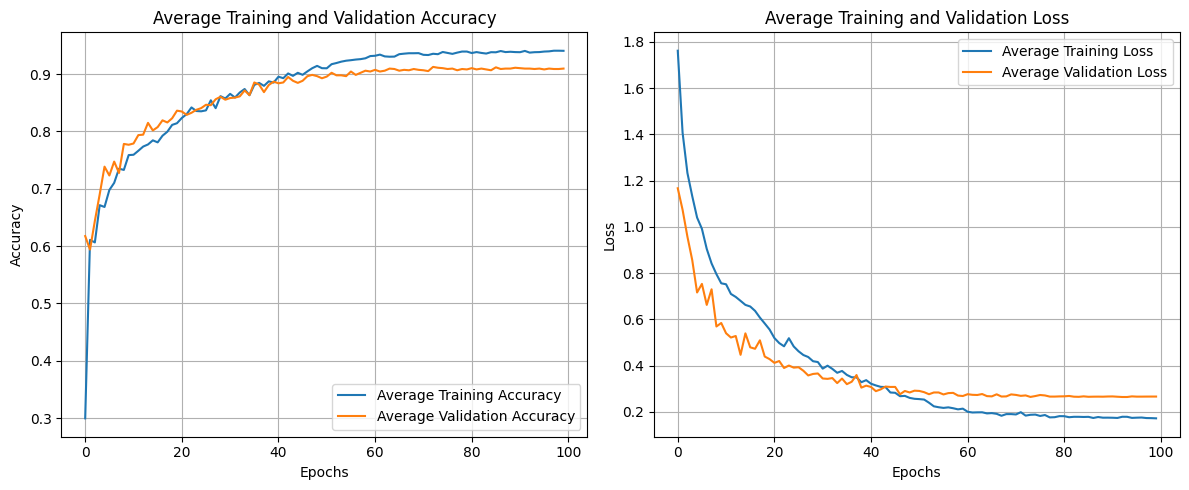

In [16]:
def plot_kfold_history(histories):
    
    all_train_loss = [h.history['loss'] for h in histories]
    all_val_loss = [h.history['val_loss'] for h in histories]
    all_train_acc = [h.history['accuracy'] for h in histories]
    all_val_acc = [h.history['val_accuracy'] for h in histories]

    max_epochs = max(len(h) for h in all_train_loss)
    
    def pad_history(hist_list):
        padded_hist = []
        for hist in hist_list:
            if len(hist) < max_epochs:
                padded_hist.append(hist + [hist[-1]] * (max_epochs - len(hist)))
            else:
                padded_hist.append(hist)
        return np.array(padded_hist)

    avg_train_loss = np.mean(pad_history(all_train_loss), axis=0)
    avg_val_loss = np.mean(pad_history(all_val_loss), axis=0)
    avg_train_acc = np.mean(pad_history(all_train_acc), axis=0)
    avg_val_acc = np.mean(pad_history(all_val_acc), axis=0)
    
    epochs_range = range(max_epochs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, avg_train_acc, label='Average Training Accuracy')
    plt.plot(epochs_range, avg_val_acc, label='Average Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Average Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, avg_train_loss, label='Average Training Loss')
    plt.plot(epochs_range, avg_val_loss, label='Average Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Average Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_kfold_history(histories)


----------------------------------- Final Results -----------------------------------
                precision    recall  f1-score   support

          COPD       0.98      0.95      0.97       793
       Healthy       0.37      0.63      0.47        35
          URTI       0.82      0.78      0.80       138
Bronchiectasis       0.96      0.96      0.96        96
     Pneumoina       0.88      0.89      0.88       222
 Bronchiolitis       0.84      0.85      0.84        78

      accuracy                           0.91      1362
     macro avg       0.81      0.84      0.82      1362
  weighted avg       0.92      0.91      0.92      1362



C:\Users\naman\AppData\Local\Temp\ipykernel_23792\1746643118.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


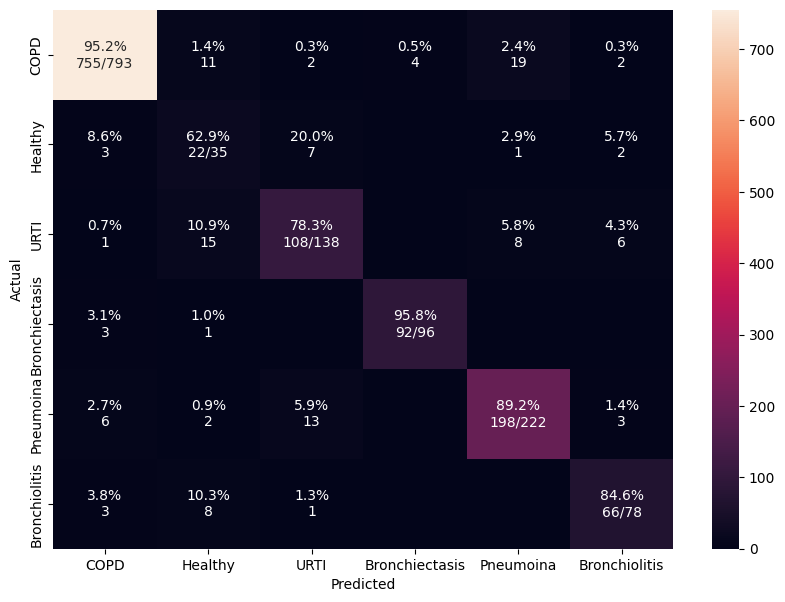

In [17]:
print("\n----------------------------------- Final Results -----------------------------------")
matrix_index = ["COPD", "Healthy", "URTI", "Bronchiectasis", "Pneumoina", "Bronchiolitis"]
print(classification_report(all_y_test, all_preds, target_names=matrix_index))

cm = confusion_matrix(all_y_test, all_preds)
cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100
annot = np.empty_like(cm).astype(str)
nrows, ncols = cm.shape
for i in range(nrows):
    for j in range(ncols):
        c = cm[i, j]
        p = cm_perc[i, j]
        if i == j:
            s = cm_sum[i]
            annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
        elif c == 0:
            annot[i, j] = ''
        else:
            annot[i, j] = '%.1f%%\n%d' % (p, c)

df_cm = pd.DataFrame(cm, index = matrix_index, columns = matrix_index)
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
fig, ax = plt.subplots(figsize=(10,7))
sn.heatmap(df_cm, annot=annot, fmt='')
plt.show()

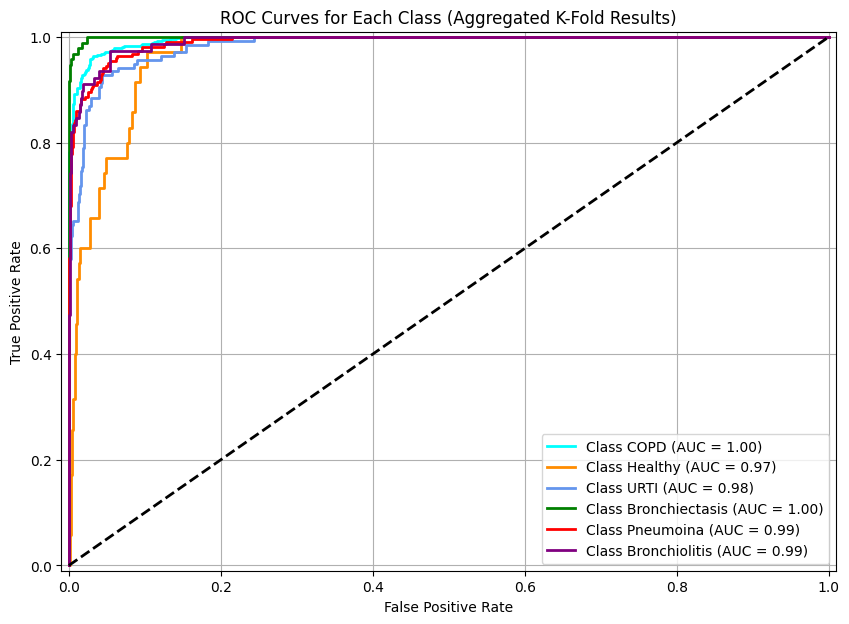

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

all_y_test_cat = np.array(all_y_test_cat)
all_prob_preds = np.array(all_prob_preds)

n_classes = all_y_test_cat.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_y_test_cat[:, i], all_prob_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {matrix_index[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class (Aggregated K-Fold Results)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [19]:
import os

print(os.path.exists('final_model.h5'))

True


In [20]:
from tensorflow.keras.models import load_model

model_loaded = load_model('final_model.h5')
model_loaded.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_12 (Conv1D)          (None, 189, 64)           384       
                                                                 
 max_pooling1d_12 (MaxPooli  (None, 94, 64)            0         
 ng1D)                                                           
                                                                 
 conv1d_13 (Conv1D)          (None, 90, 128)           41088     
                                                                 
 max_pooling1d_13 (MaxPooli  (None, 45, 128)           0         
 ng1D)                                                           
                                                                 
 dropout_6 (Dropout)         (None, 45, 128)           0         
                                                                 
 lstm_6 (LSTM)               (None, 45, 64)           

In [22]:
import os 

index_to_label = {0: "COPD", 1: "Healthy", 2: "URTI", 3: "Bronchiectasis", 4: "Pneumonia", 5: "Bronchiolitis"}

def get_diagnosis_dict():
    diagnosis_list = diagnosis_data()
    diag_dict = {}
    for diag_obj in diagnosis_list:
        try:
            filename = os.path.basename(diag_obj.image_path)
            patient_id = int(filename.split('_')[0])
            diag_dict[patient_id] = diag_obj.diagnosis
        except (ValueError, IndexError) as e:
            print(f"Skipping malformed filename: {diag_obj.image_path} - Error: {e}")
            continue
    return diag_dict

diagnosis_dict = get_diagnosis_dict()

def predict_disease_from_audio(file_path):
    filename = os.path.basename(file_path)
    
    try:
        patient_id = int(filename.split('_')[0])
        actual_disease = diagnosis_dict.get(patient_id, "Unknown")
    except (ValueError, IndexError) as e:
        actual_disease = "Unknown (Error in filename)"
        print(f"Could not parse patient ID from filename: {filename} - Error: {e}")
    
    features = audio_features(file_path)
    
    features = np.reshape(features, (1, features.shape[0], 1))
    
    prediction = model_loaded.predict(features, verbose=0)
    predicted_class = np.argmax(prediction)
    predicted_label = index_to_label[predicted_class]
    
    print(f" Predicted Disease: {predicted_label}")
    print(f"Prediction Probabilities:\n{dict(zip(index_to_label.values(), prediction[0]))}")

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/117_1b3_Tc_mc_LittC2SE.wav'
predict_disease_from_audio(test_file_path)

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/121_1p1_Tc_sc_Meditron.wav'
predict_disease_from_audio(test_file_path)

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/226_1b1_Pl_sc_LittC2SE.wav'
predict_disease_from_audio(test_file_path)


C:\Users\naman\AppData\Local\Temp\ipykernel_23792\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


 Predicted Disease: Bronchiectasis
Prediction Probabilities:
{'COPD': 0.26687106, 'Healthy': 0.09026382, 'URTI': 0.03186371, 'Bronchiectasis': 0.58623934, 'Pneumonia': 8.161543e-05, 'Bronchiolitis': 0.024680393}
 Predicted Disease: Healthy
Prediction Probabilities:
{'COPD': 0.036607694, 'Healthy': 0.89958996, 'URTI': 0.02693157, 'Bronchiectasis': 0.0007391223, 'Pneumonia': 6.847766e-05, 'Bronchiolitis': 0.036063284}
 Predicted Disease: Healthy
Prediction Probabilities:
{'COPD': 0.02873773, 'Healthy': 0.5147905, 'URTI': 0.28068694, 'Bronchiectasis': 0.00018722894, 'Pneumonia': 0.119465895, 'Bronchiolitis': 0.0561317}


In [23]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
plot_model(model_loaded, to_file='cnn_model_loaded.png', show_shapes=True, show_layer_names=True)
plt.imshow(plt.imread('cnn_model_loaded.png'))
plt.axis('off')
plt.show()

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


FileNotFoundError: [Errno 2] No such file or directory: 'cnn_model_loaded.png'